### This tutorial shows division members who have been assigned the User role in the Data Store how to register inventory objects used in the synthetic “Material Synthesis” example. You will review the inventory structure prepared by Data Store Stewards, register one Sample manually, and batch-register additional samples in the FB Inventory.

### Key Concepts

The Data Store has two Inventory sections: FB Inventory and BAM Inventory. By default, objects in the FB Inventory are available to the relevant division. Access can also be granted to collaborators from other divisions. Objects in the BAM Inventory are visible to BAM members with access to the Data Store.

Each division has four FB Inventory spaces: Equipment, Materials, Methods, and Publications. These spaces are identified by the division number, for example, X.1 Equipment and X.1 Materials. The BAM Inventory contains institution-wide spaces, such as BAM Equipment, with predefined division-specific projects, such as X.1 Equipment Open.

### Note: Please replace X.1 with your division number for the entirety of the tutorial.

### Required Libraries' Installation

In [ ]:
%pip install pybis
%pip install openpyxl

### Importing Important Libraries

In [ ]:
from pybis import Openbis# Used to access the Data Store
import pandas as pd# Used in step 3 to read data from the 'samples.xlsx' file

### Creating an openBIS object and setting the session token

To log in using a session token,

1. Log in to the Bam Data Store website
2. Go to the Tools tab on the top left
3. Select User Profile from the list of options provided
4. Copy the OpenBIS session token and use it in the next cell.

In [ ]:
o = Openbis("https://playground.datastore.bam.de/")

o.set_token("your_token_here") # Replace with your actual token

# Step 1: Review the prepared inventory structure

In this step, you need to confirm that the spaces, projects, collections and objects exist in the inventory.

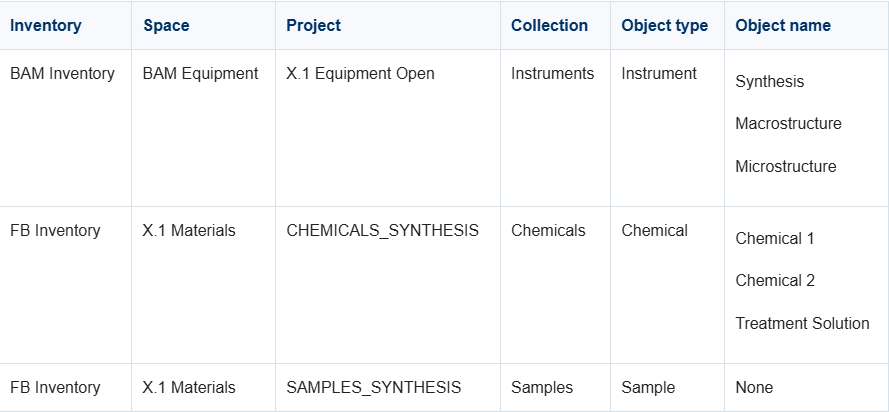

In [ ]:
# print(o.get_spaces()) #uncomment this if you do not know the space's code to see all the spaces and find the code for BAM_EQUIPMENT in the table displayed
myspace = o.get_space('BAM_EQUIPMENT')#input the space's code here to save it in the myspace variable

In [ ]:
# myspace.get_projects()#uncomment this to see all the projects in the space and find the code for X.1_EQUIPMENT_OPEN in the table displayed

In [ ]:
proj = myspace.get_project('X.1_EQUIPMENT_OPEN')# The code that was found in the previous step is to be used here to save the project in the proj variable
for x in proj.get_collections():# loop used to print the attributes of all the collections in the project.
    print(x.props.all())# Index for 'Instruments' is to be used in the next cell.

In [ ]:
col = proj.get_collections()[2]# 2 is the index for 'Instruments' in the list of collections printed in the previous cell. Use this to save the collection in the col variable.
col.props.all()# displaying properties of 'Instruments' collection

### Please make sure that you see these objects as the output for the next cell:
Synthesis

Macrostructure

Microstructure

In [ ]:
for x in col.get_objects():
    print(x.props('$name'))

In [ ]:
myspace = o.get_space('X.1_MATERIALS')# please use the code X.1_MATERIALS to save the space in the myspace variable
myspace.get_projects()#this is used for displaying all the projects in the space and finding the code for CHEMICALS_SYNTHESIS in the table displayed

In [ ]:
proj = myspace.get_project('CHEMICALS_SYNTHESIS')# The code that was found for chemicals_synthesis in the previous step is to be used here to save the project in the proj variable
proj.attrs.all() #displaying attributes of the project CHEMICALS_SYNTHESIS

In [ ]:
for x in proj.get_collections(): # loop used to print the attributes of all the collections in the project.
    print(x.props.all())# Index for 'Chemicals' is to be used in the next cell.

In [ ]:
col = proj.get_collections()[0] # 0 is the index for 'Chemicals' in the list of collections printed in the previous cell. Use this to save the collection in the col variable.
col.props.all() #displaying attributes of the collection 'Chemicals' 

### Please make sure that you see these objects as the output for the next cell:
Chemical 1

Chemical 2

Treatment Solution

In [ ]:
for x in col.get_objects():
    print(x.props('$name'))

In [ ]:
myspace = o.get_space('X.1_MATERIALS')# please use the code X.1_MATERIALS to save the space in the myspace variable
myspace.get_projects()#this is used for displaying all the projects in the space and finding the code for samples_synthesis in the table displayed

In [ ]:
proj = myspace.get_project('SAMPLES_SYNTHESIS')# The code that was found for samples_synthesis in the previous step is to be used here to save the project in the proj variable
proj.attrs.all()

In [ ]:
# Index for 'Samples' is to be used in the next cell.
for x in proj.get_collections():
    print(x.props.all())

In [ ]:
col = proj.get_collections()[0]# 0 is the index for 'Samples' in the list of collections printed in the previous cell. Use this to save the collection in the col variable.
col.props.all()

In [ ]:
for x in col.get_samples(): # this cell will display the names of all the samples in the collection 'Samples'
    print(x.props('$name'))

# Step 2: Register one Sample

Register one Sample in the SAMPLES collection. Enter your Data Store username in the Co-responsible person property so that other users can distinguish who registers and shares responsibility for the Sample.

In [ ]:
myspace = o.get_space('X.1_MATERIALS')
# myspace.get_projects()#use this to see all the projects in your space and find the code for SAMPLES_SYNTHESIS in the table displayed

In [ ]:
proj = myspace.get_project('SAMPLES_SYNTHESIS')# Use the code that was found for SAMPLES_SYNTHESIS in the previous step to save the project in the proj variable
proj.get_collections()#Please find the index for the collection 'Samples' in the list of collections printed in the output of this cell. The index will be used in the next cell.

In [ ]:
col = proj.get_collections()[0]# 0 is the index for 'Samples' in the list of collections printed in the previous cell. Use this to save the collection in the col variable.
col.props.all()

In [ ]:
#Please add the following details to the new sample that you are going to create in this cell:
#props      = {"$name": "Synthesized Material", 'co_responsible_person': "/BAM_GLOBAL/BAM_DATA/Username", 'bam_oe': 'OE_X.1'} 

# please make sure to use your username here : /BAM_GLOBAL/BAM_DATA/your_username
sample = o.new_sample(
    type       = 'SAMPLE',
    experiment =  col,
    props      = {"$name": "Synthesized Material", 'co_responsible_person': "/BAM_GLOBAL/BAM_DATA/your_username", 'bam_oe': 'OE_X.1'}#please replace X.1 with the code for your division
)
sample

In [ ]:
sample.save()# saving the sample into openBIS

# Step 3: Batch-register Samples

Use the supplied Excel file (samples.xlsx) to register multiple Sample objects in one operation. 

The samples will be registered in the same collection that was used in step 2.

### Terminology in Excel files:
Because of an unresolved terminology issue in openBIS 20.10.12, generated and exported Excel files use labels that differ from those in the current openBIS user interface:

Experiment corresponds to a collection.
Sample Type corresponds to an object type.
When completing an Excel file, do not rename the columns. openBIS requires the original column headings for batch registration and batch update.

In [ ]:
# Reading the Excel file 'samples.xlsx
df = pd.read_excel(
    "samples.xlsx",
    header=None,
    engine="openpyxl",
    dtype=str
)

#removing the first 4 rows and setting the 4th row as the header for the dataframe
#removing all the columns with None values
df.columns = df.iloc[3]
df = df.iloc[4:].reset_index(drop=True)
df = df.dropna(axis=1, how="all")
df

In [ ]:
df.columns#displaying the columns after removing the columnms with None values

### The next cell formats 'Complete BAM Location' into a format acceptable for the data store
e.g UE_08_0_118 is accepted as complete bam location, not UE/08/0/118

In [ ]:
# Replacing forward slashes with underscores in the 'Complete BAM Location' column
df["Complete BAM Location"] = df["Complete BAM Location"].str.replace("/","_")
df

In [ ]:
# creating the samples in a loop and saving them into openBIS
# please make sure to use your username here : /BAM_GLOBAL/BAM_DATA/your_username
for index in range(len(df)):
    sample = o.new_sample(
        type       = 'SAMPLE',
        experiment =  col,
        props      = {"$name": str(df["Name"][index]), 'co_responsible_person': "/BAM_GLOBAL/BAM_DATA/your_username", 'bam_oe': str(df["BAM Organizational Entity"][index]),
                    'bam_location_complete': str(df["Complete BAM Location"][index]), 'manufacturer': str(df["Manufacturer"][index])}
    )
    sample.save()